In [2]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import fontManager
import matplotlib as mpl

# 設定字型（使用系統內建中文字型，如微軟正黑體或SimHei）
mpl.rcParams['font.family'] = 'SimHei'  # Windows 常用字型，如 SimHei、Microsoft JhengHei
mpl.rcParams['axes.unicode_minus'] = False  # 解決負號顯示問題


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
模型準確率: 1.00
分類報告:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



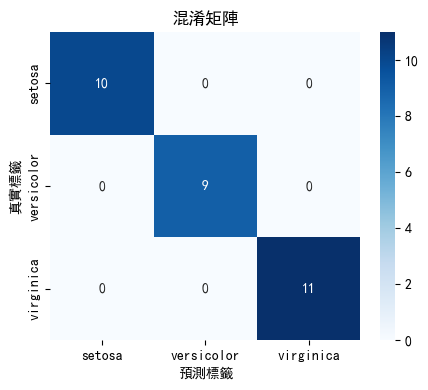

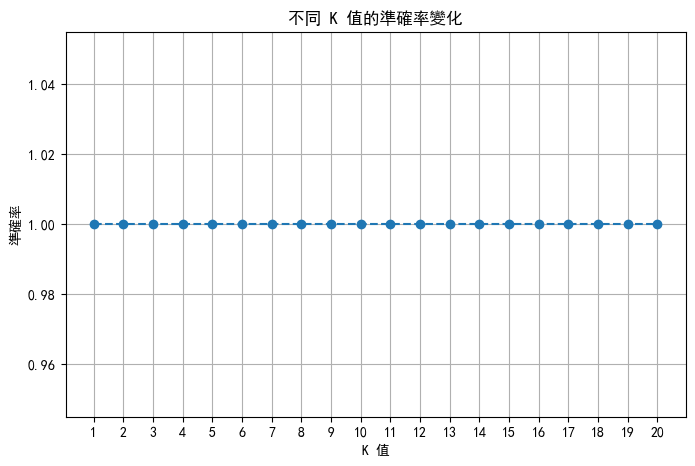

In [3]:
# 實驗：KNN（K-Nearest Neighbors）分類

# 步驟 1：導入必要的庫
import numpy as np
import pandas as pd
#import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 步驟 2：加載並檢視數據
iris = load_iris()
X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
print(df.head())

# 步驟 3：數據預處理
# 拆分訓練集與測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 特徵標準化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 步驟 4：訓練 KNN 模型
k = 3
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# 步驟 5：模型評估
# 準確率
accuracy = accuracy_score(y_test, y_pred)
print(f"模型準確率: {accuracy:.2f}")

# 分類報告
print("分類報告:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# 混淆矩陣
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('預測標籤')
plt.ylabel('真實標籤')
plt.title('混淆矩陣')
plt.show()

# 步驟 6：選擇最佳的 K 值
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

# 繪製 K 值與準確率的關係圖
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='dashed')
plt.xlabel("K 值")
plt.ylabel("準確率")
plt.title("不同 K 值的準確率變化")
plt.xticks(k_values)
plt.grid()
plt.show()
